# Vehicle Price Prediction with Machine Learning

## Project Overview
This project explores machine learning approaches for predicting vehicle prices using structured automotive data. The notebook investigates how preprocessing, feature selection, normalization, and neural network design influence regression model performance.

## Objectives
- Explore and preprocess structured automotive data
- Compare regression approaches using neural networks
- Evaluate the impact of feature normalization
- Combine numerical and categorical features into a final predictive model

## Technologies Used
- Python
- Pandas
- TensorFlow / Keras
- Scikit-learn
- Matplotlib

## Key Learning Outcomes
Through this project, I strengthened my understanding of:
- data preprocessing and feature engineering
- normalization and training stability
- neural network regression workflows
- handling mixed numerical and categorical datasets
- evaluating and refining ML model performance


In [29]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


#DATA PREPROCESSING STEPS
#https://www.javatpoint.com/data-preprocessing-machine-learning

## Setup

Let's start by importing our dependencies.

In [66]:
%reset -f


!pip install -r requirements.txt


import numpy as np
import pandas as pd
import math

import tensorflow as tf



## Pandas, a helpful data analysis library for in-memory dataset

We use a package called [Pandas](http://pandas.pydata.org/) for reading in our data, exploring our data and doing some basic processing. It is really helpful for datasets that fit in memory! And it has some nice integrations, as you will see.

First we set up some options to control how items are displayed and the maximum number of rows to show when displaying a table.  Feel free to change this setup to whatever you'd like.

In [41]:
# Set pandas output display to have one digit for decimal places and limit it to
# printing 15 rows.
pd.options.display.float_format = '{:.1f}'.format
pd.options.display.max_rows = 15

### Load the dataset with pandas
The car data set we will be using in this lab is provided as a comma separated file without a header row.  In order for each column to have a meaningful header name we must provide it.  We get the information about the columns from the [Automobile Data Set](https://archive.ics.uci.edu/ml/datasets/automobile).

We will use the features of the car, to try to predict its price.


In [42]:
# Provide the names for the columns since the CSV file with the data does
# not have a header row.
feature_names = ['symboling', 'normalized-losses', 'make', 'fuel-type',
        'aspiration', 'num-doors', 'body-style', 'drive-wheels',
        'engine-location', 'wheel-base', 'length', 'width', 'height', 'weight',
        'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore',
        'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
        'highway-mpg', 'price']


# Load in the data from a CSV file that is comma separated.
car_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cars_data.csv',
                        sep=',', names=feature_names, header=None, encoding='latin-1')

#Exporting to csv with columns names
car_data.to_csv('car_data.csv', index=False)


# We'll then randomize the data, just to be sure not to get any pathological
# ordering effects that might harm the performance of Stochastic Gradient
# Descent.
car_data = car_data.reindex(np.random.permutation(car_data.index))

print("Data set loaded. Num examples: ", len(car_data))
car_data.head()

Data set loaded. Num examples:  205


,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
196,-2,103,volvo,gas,std,four,sedan,rwd,front,104.3,...,141,mpfi,3.78,3.15,9.5,114,5400,24,28,15985
94,1,128,nissan,gas,std,two,sedan,fwd,front,94.5,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,7299
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
49,0,?,jaguar,gas,std,two,sedan,rwd,front,102.0,...,326,mpfi,3.54,2.76,11.5,262,5000,13,17,36000
85,1,125,mitsubishi,gas,std,four,sedan,fwd,front,96.3,...,122,2bbl,3.35,3.46,8.5,88,5000,25,32,6989


## Explore and prepare the data


Useful functions:
- `type()` called on any Python object describes the type of the object
- `dataframe[4:7]` pulls out rows 4, 5, 6 in a Pandas dataframe
- `dataframe[['mycol1', 'mycol2']]` pulls out the two requested columns into a new Pandas dataframe
- `dataframe['mycol1']` returns a Pandas series -- not a dataframe!
- `dataframe.describe()` prints out statistics for each dataframe column

In [43]:
car_data[4:7]

,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
85,1,125,mitsubishi,gas,std,four,sedan,fwd,front,96.3,...,122,2bbl,3.35,3.46,8.5,88,5000,25,32,6989
198,-2,103,volvo,gas,turbo,four,sedan,rwd,front,104.3,...,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18420
120,1,154,plymouth,gas,std,four,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.4,68,5500,31,38,6229


In [44]:
LABEL = 'price'

numeric_feature_names = car_data[['symboling', 'normalized-losses', 'wheel-base',
        'length', 'width', 'height', 'weight', 'engine-size', 'horsepower',
        'peak-rpm', 'city-mpg', 'highway-mpg', 'bore', 'stroke',
         'compression-ratio']].columns.tolist()

categorical_feature_names = list(set(feature_names) - set(numeric_feature_names) - set([LABEL]))
print(len(numeric_feature_names))
# The correct solution will pass these assert statements.
assert len(numeric_feature_names) == 15
assert len(categorical_feature_names) == 10

15


In [45]:
# Run to inspect numeric features.
car_data[numeric_feature_names]

,symboling,normalized-losses,wheel-base,length,width,height,weight,engine-size,horsepower,peak-rpm,city-mpg,highway-mpg,bore,stroke,compression-ratio
196,-2,103,104.3,188.8,67.2,56.2,2935,141,114,5400,24,28,3.78,3.15,9.5
94,1,128,94.5,165.3,63.8,54.5,1951,97,69,5200,31,37,3.15,3.29,9.4
200,-1,95,109.1,188.8,68.9,55.5,2952,141,114,5400,23,28,3.78,3.15,9.5
49,0,?,102.0,191.7,70.6,47.8,3950,326,262,5000,13,17,3.54,2.76,11.5
85,1,125,96.3,172.4,65.4,51.6,2365,122,88,5000,25,32,3.35,3.46,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,3,?,89.5,168.9,65.0,51.6,2800,194,207,5900,17,25,3.74,2.90,9.5
29,3,145,95.9,173.2,66.3,50.2,2811,156,145,5000,19,24,3.60,3.90,7.0
27,1,148,93.7,157.3,63.8,50.6,2191,98,102,5500,24,30,3.03,3.39,7.6
119,1,119,93.7,157.3,63.8,50.8,2128,98,102,5500,24,30,3.03,3.39,7.6


In [46]:
# Run to inspect categorical features.
car_data[categorical_feature_names]

,aspiration,engine-location,body-style,num-cylinders,drive-wheels,num-doors,make,fuel-system,fuel-type,engine-type
196,std,front,sedan,four,rwd,four,volvo,mpfi,gas,ohc
94,std,front,sedan,four,fwd,two,nissan,2bbl,gas,ohc
200,std,front,sedan,four,rwd,four,volvo,mpfi,gas,ohc
49,std,front,sedan,twelve,rwd,two,jaguar,mpfi,gas,ohcv
85,std,front,sedan,four,fwd,four,mitsubishi,2bbl,gas,ohc
...,...,...,...,...,...,...,...,...,...,...
128,std,rear,convertible,six,rwd,two,porsche,mpfi,gas,ohcf
29,turbo,front,hatchback,four,fwd,two,dodge,mfi,gas,ohc
27,turbo,front,sedan,four,fwd,?,dodge,mpfi,gas,ohc
119,turbo,front,hatchback,four,fwd,two,plymouth,spdi,gas,ohc


In [47]:
# Coerce the numeric features to numbers. This is necessary because the model
# crashes because not all the values are numeric.
for feature_name in numeric_feature_names + [LABEL]:
  car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')

missing_values = car_data.isna().sum()

missing_values[missing_values > 0]

# Fill missing values with 0.
# Is this an OK thing to do? You may want to come back and revisit this decision later.
#car_data.fillna(0, inplace=True)


original_length = len(car_data)

car_data.drop(labels='normalized-losses', axis=1, inplace=True)

numeric_feature_names = list(set(numeric_feature_names) - set(['normalized-losses']))

car_data.dropna(inplace=True)

new_length = len(car_data)

print('Dropped {} rows with missing data'.format(original_length - new_length))
print(len(car_data))


Dropped 10 rows with missing data
195


## Best model with numeric features. No normalization.

Various hyperparameters can be changed:
- learning rate
- choice of optimizer
- hidden layer dimensions -- make sure your choice here makes sense given the number of training examples
- batch size
- num training steps
- (anything else you can think of changing)

Do not use the `normalizer_fn` arg on `numeric_column`.

In [50]:
batch_size = 16

print(numeric_feature_names)
x_df = car_data[numeric_feature_names]
y_series = car_data['price']

x_df.reset_index(drop=True, inplace=True)
y_series.reset_index(drop=True, inplace=True)

# 1. Replaces feature_columns and defines the network structure
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(numeric_feature_names),)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # The output layer for predicting price
])

# 2. Replaces DNNRegressor configuration and optimizer settings
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# 3. Replaces the manual train/evaluate loop and input_fn's
print("Starting training...")
history = model.fit(
    x_df,
    y_series,
    epochs=100,
    batch_size=batch_size,
    validation_split=0.2, # Evaluates on 20% of the data at the end of every epoch
    verbose=1
)

# Optional final evaluation
final_scores = model.evaluate(x_df, y_series, verbose=0)
print(f"Final Loss (MSE): {final_scores[0]}, Final MAE: {final_scores[1]}")

['weight', 'horsepower', 'compression-ratio', 'bore', 'peak-rpm', 'city-mpg', 'stroke', 'wheel-base', 'highway-mpg', 'engine-size', 'length', 'height', 'width', 'symboling']
Starting training...
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 227746496.0000 - mean_absolute_error: 12728.4980 - val_loss: 147082928.0000 - val_mean_absolute_error: 10429.1777
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 145314560.0000 - mean_absolute_error: 8737.1543 - val_loss: 67858520.0000 - val_mean_absolute_error: 5761.3677
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 75619528.0000 - mean_absolute_error: 5593.9609 - val_loss: 32646860.0000 - val_mean_absolute_error: 4443.7812
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 59384584.0000 - mean_absolute_error: 6108.3457 - val_loss: 39624676.0000 - val_mean_absolute_error: 5145.6738
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 58238740.0000 - mean_absolute_error: 6116.4673 - val_loss: 32

### For multiple optimizers analysis

Trial 18 Complete [00h 00m 10s]
mse: 39023354.0

Best mse So Far: 34722118.0
Total elapsed time: 00h 02m 47s
Optimal hyperparameters found:
Optimizer: RMSprop
Learning Rate: 0.01
Batch Size: 16
Units in layer 1: 64
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 113853424.0000 - mse: 113853424.0000 - val_loss: 55024832.0000 - val_mse: 55024832.0000
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 59853148.0000 - mse: 59853148.0000 - val_loss: 35916576.0000 - val_mse: 35916576.0000
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 51699496.0000 - mse: 51699496.0000 - val_loss: 33247556.0000 - val_mse: 33247556.0000
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 49640440.0000 - mse: 49640440.0000 - val_loss: 26618934.0000 - val_mse: 26618934.0000
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 38250856.0000 - mse: 38250856.0000 - val_loss: 44996768.0000 - val_mse: 44996768.0000
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 48287980.0000 - mse: 48287980.0000 - val_loss: 25351584.0000 - val_mse: 25351584.0000
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 33465956.0000 - mse: 33465956.0000 - val_loss: 17913238.0000 - val_mse: 17913238.0000
Epoch 8/

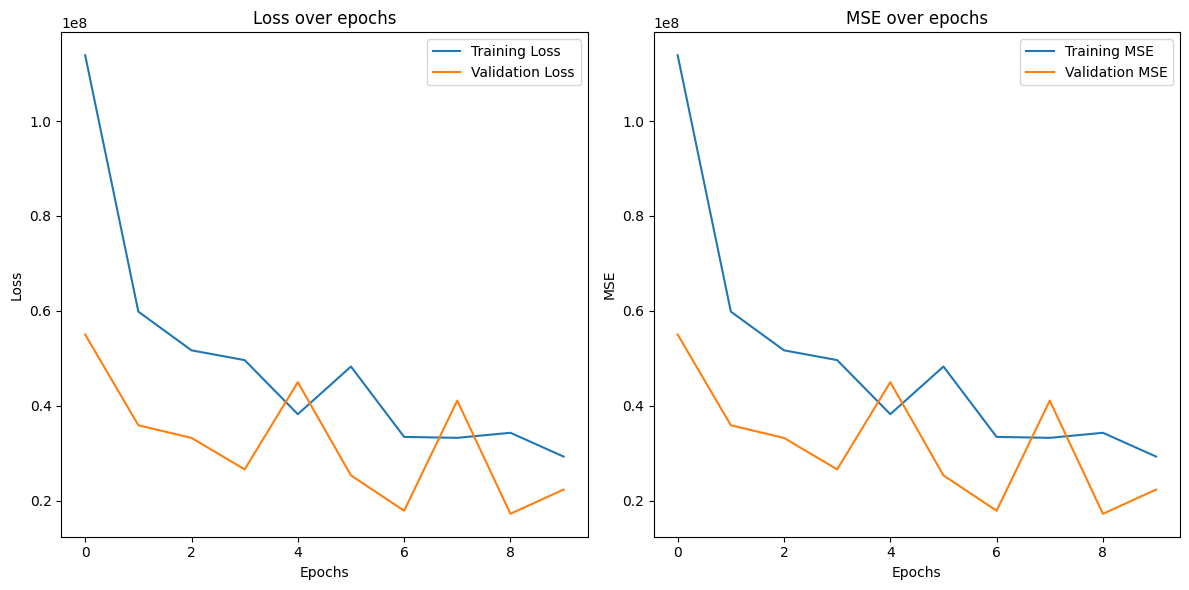

In [51]:
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adagrad, Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

x_df = car_data[numeric_feature_names]
y_series = car_data['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x_df, y_series, test_size=0.2, random_state=42)


# Delete the previous tuner results to start fresh
shutil.rmtree('tuner_results', ignore_errors=True)

# Define the model-building function with Keras Tuner hyperparameters
def build_model(hp):
    model = Sequential()
    # Input layer based on the number of numeric features
    model.add(Dense(units=hp.Int('units_input', min_value=64, max_value=128, step=32),
                    activation='relu', input_dim=X_train.shape[1]))

    # Hidden layers with varying units
    for i in range(hp.Int('num_layers', 1, 2)):  # 1 to 2 hidden layers
        model.add(Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=64, step=16), activation='relu'))

    # Output layer
    model.add(Dense(1, activation='linear'))

    # Select optimizer and learning rate
    optimizer_name = hp.Choice('optimizer', ['Adagrad', 'Adam', 'RMSprop'])
    learning_rate = hp.Choice('learning_rate', [0.001, 0.01, 0.1])

    if optimizer_name == 'Adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)

    # Define batch size as a hyperparameter
    batch_size = hp.Int('batch_size', 16, 32, step=8)

    # Compile the model
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])
    return model

# Initialize the Keras Tuner with Random Search
tuner = kt.RandomSearch(
    build_model,
    objective='mse',
    max_trials=18,  # Number of hyperparameter combinations to try
    executions_per_trial=2,  # Average results across 3 executions
    directory='tuner_results',
    project_name='car_price_prediction'
)

# Display summary of the search space
tuner.search_space_summary()

# Early stopping callback to avoid wasting time on poor-performing models
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

tuner.search(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[early_stopping])

# Retrieve the best model and hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Optimal hyperparameters found:")
print(f"Optimizer: {best_hps.get('optimizer')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")
print(f"Batch Size: {best_hps.get('batch_size')}")
for i in range(best_hps.get('num_layers')):
    print(f"Units in layer {i+1}: {best_hps.get(f'units_{i}')}")

# Build the best model and fit it on the full dataset
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, y_train, epochs=10, batch_size=best_hps.get('batch_size'), validation_split=0.2)

# Evaluate the model's performance
loss, mse = best_model.evaluate(X_test, y_test)
print(f"Final MSE on test set: {mse}")

#Retrieve the list of trials
trials = tuner.oracle.trials

# Prepare the data for the table
optimizer_list = []
learning_rate_list = []
loss_list = []

# Loop through each trial and extract the relevant data
for trial in trials.values():
    # Get hyperparameters
    optimizer = trial.hyperparameters['optimizer']
    learning_rate = trial.hyperparameters['learning_rate']
    loss = trial.metrics.get_best_value('loss')

    # Append the values to their respective lists
    optimizer_list.append(optimizer)
    learning_rate_list.append(learning_rate)
    loss_list.append(loss)

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Optimizer': optimizer_list,
    'Learning Rate': learning_rate_list,
    'Training Loss': loss_list
})

# Convert results_df['Training Loss'] to numeric to ensure aggregation works properly
results_df['Training Loss'] = pd.to_numeric(results_df['Training Loss'], errors='coerce')

# Group by 'Optimizer' and 'Learning Rate' and take the minimum loss for each combination
results_df = results_df.groupby(['Optimizer', 'Learning Rate'], as_index=False).min()

# Sort by training loss to see the best combinations
results_df = results_df.sort_values(by=['Optimizer', 'Learning Rate'], ascending=[True, True])

# Apply formatting only to the 'Learning Rate' column
results_df['Learning Rate'] = results_df['Learning Rate'].map('{:.3f}'.format)

# Display the comparison table
print("Comparison of Optimizers and Learning Rates:")
print(results_df)

# Calculate additional performance metrics
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

# Visualize training and validation loss/metrics
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('MSE over epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()


### Visualize your model's predictions

After model is trained, it may be helpful to understand how your model's inference differs from the actual data.

This helper function `scatter_plot_inference` does that for you. Real data is in grey. Your model's predictions are in orange.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


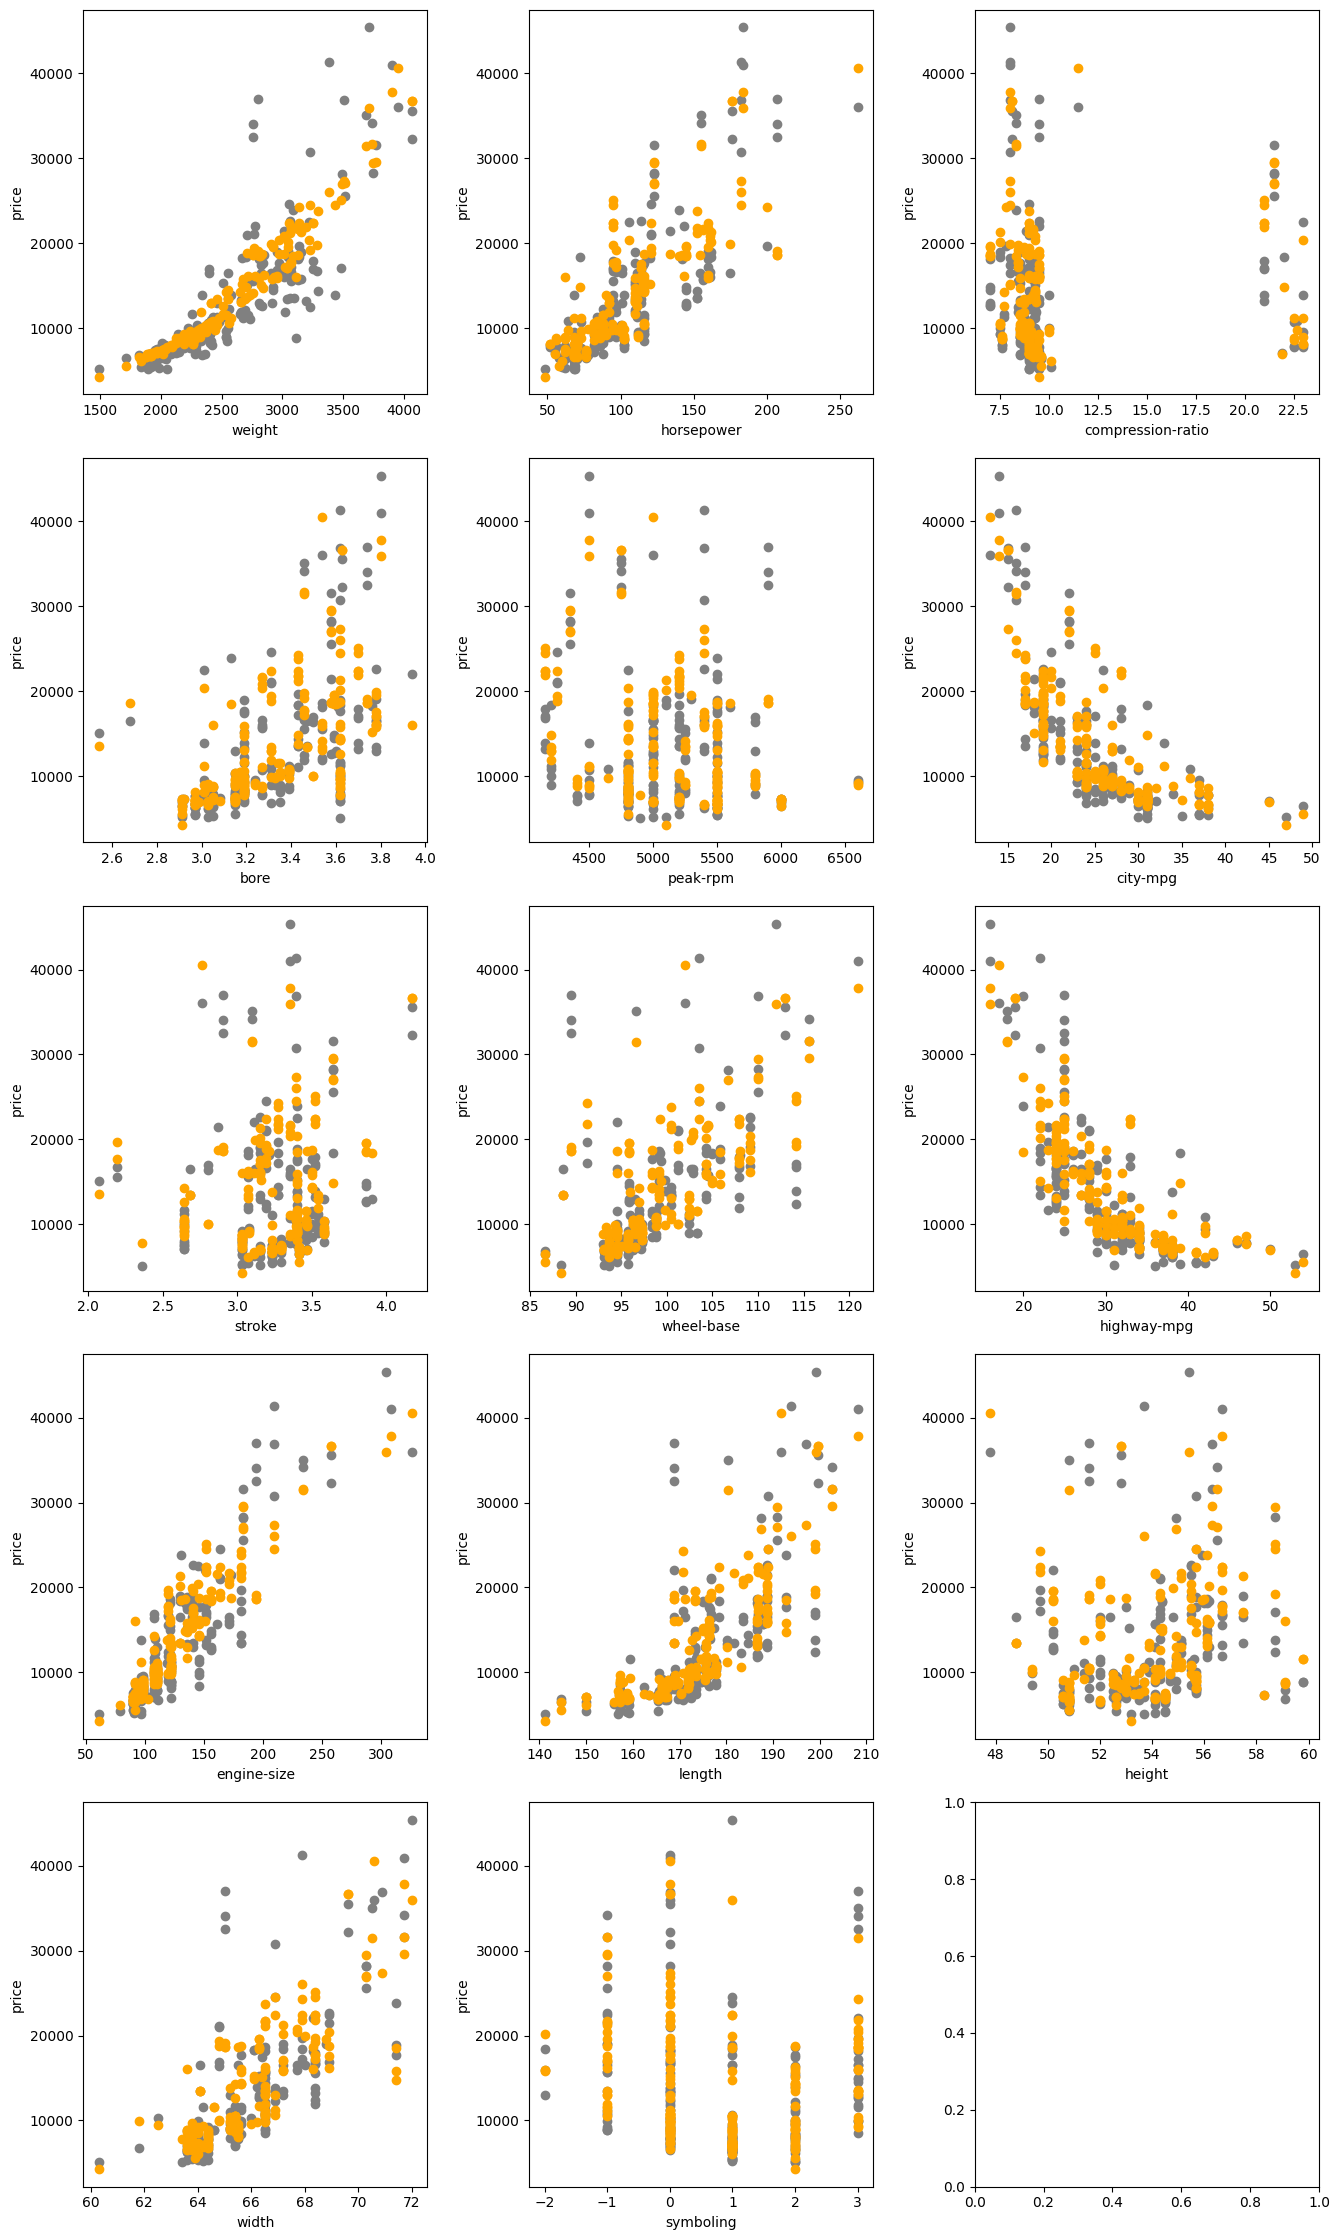

In [53]:
from matplotlib import pyplot as plt

def scatter_plot_inference_grid(model, x_df, feature_names):
  """Plots the predictions of the model against each feature.

  Args:
    model: The trained tf.keras.Model.
    x_df: The pandas dataframe with the input data.
    feature_names: An iterable of string feature names to plot.
  """
  def scatter_plot_inference(axis,
                             x_axis_feature_name,
                             y_axis_feature_name,
                             predictions):
    """Generate one subplot."""
    # Plot the real data in grey.
    y_axis_feature_name = 'price'
    axis.set_ylabel(y_axis_feature_name)
    axis.set_xlabel(x_axis_feature_name)
    axis.scatter(car_data[x_axis_feature_name],
                 car_data[y_axis_feature_name],
                 c='grey')

    # Plot the predicted data in orange.
    axis.scatter(car_data[x_axis_feature_name], predictions, c='orange')

  # Use the Keras model's predict method directly
  predictions = model.predict(x_df).flatten()

  num_cols = 3
  num_rows = int(math.ceil(len(feature_names)/float(num_cols)))

  # Handle cases where subplots returns a single Axes object or a 1D array
  if num_rows == 1 and num_cols == 1:
      f, axarr = plt.subplots(num_rows, num_cols, squeeze=False)
      axarr = axarr.flatten() # Flatten to make it iterable for consistency
  else:
      f, axarr = plt.subplots(num_rows, num_cols, squeeze=False)
      axarr = axarr.flatten() # Flatten to make it iterable

  size = 4.5
  f.set_size_inches(num_cols*size, num_rows*size)

  for i, feature_name in enumerate(numeric_feature_names):
    # Access the correct axis from the flattened array
    if i < len(axarr):
        axis = axarr[i]
        scatter_plot_inference(axis, feature_name, 'price', predictions)
    else:
        break # Should not happen if num_rows and num_cols are calculated correctly

  plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
  plt.show()

# Call the function with the Keras model
scatter_plot_inference_grid(model, x_df, numeric_feature_names)

## Best numeric model from earlier. Add normalization.

- You will need to use the `normalizer_fn` arg on [`numeric_column`](https://g3doc.corp.google.com/learning/brain/public/g3doc/api_docs/python/tf/feature_column/numeric_column.md?cl=head)

- You may find these pandas functions helpful:
    - dataframe.mean()['your_feature_name']
    - dataframe.std()['your_feature_name']


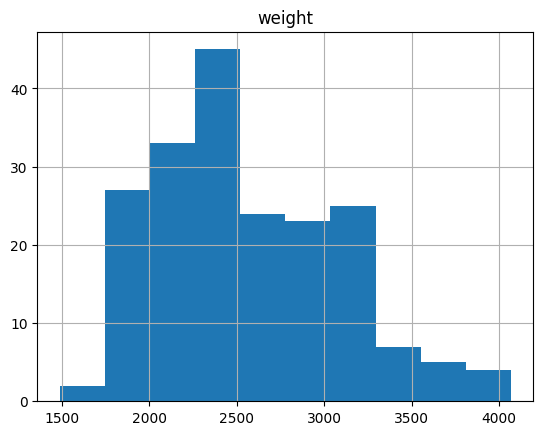

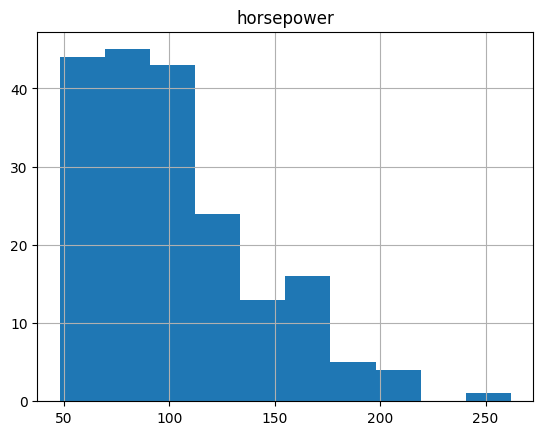

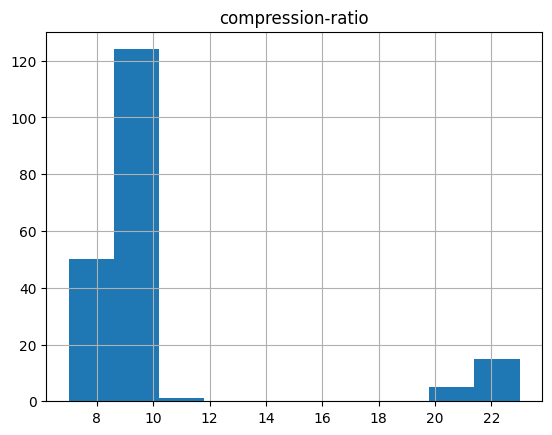

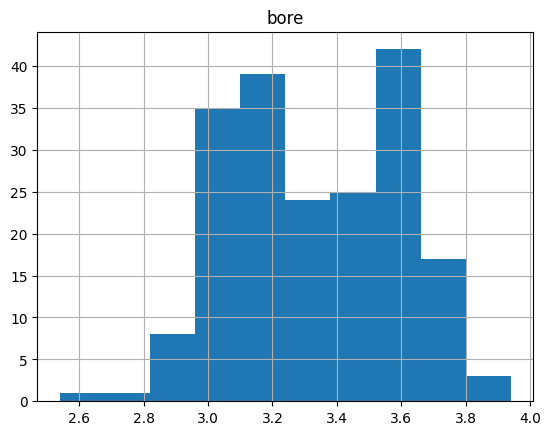

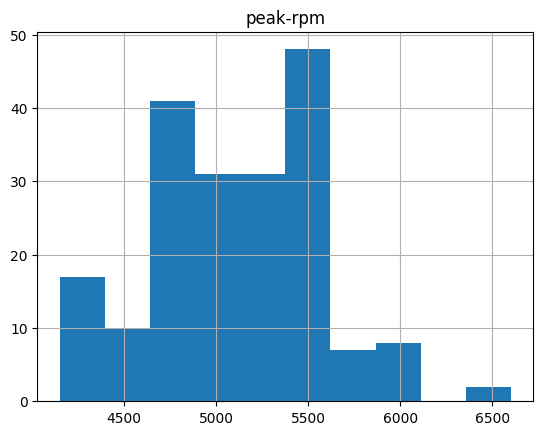

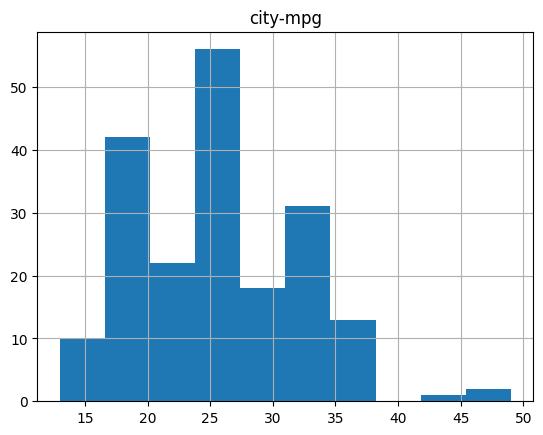

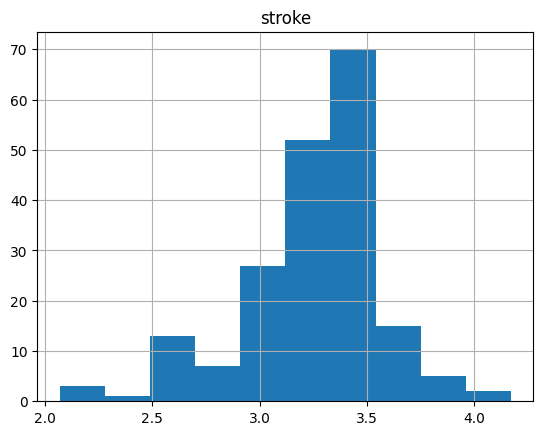

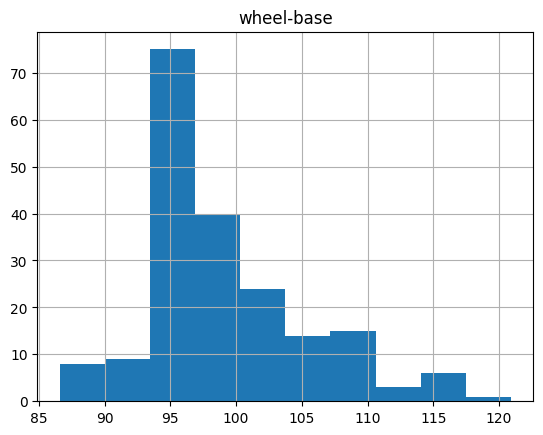

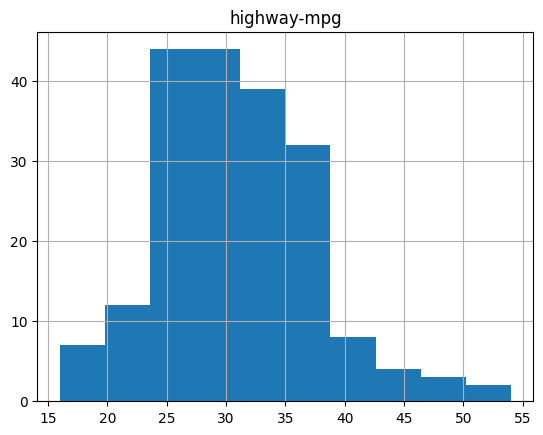

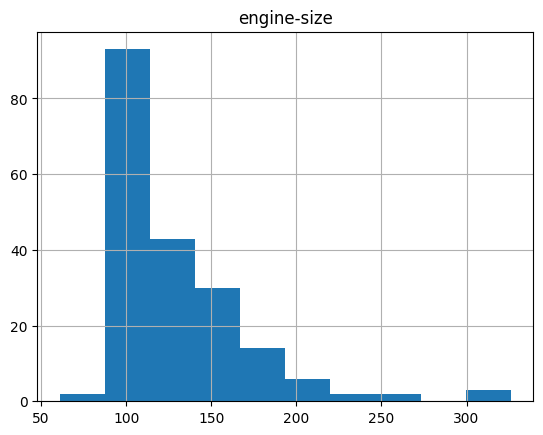

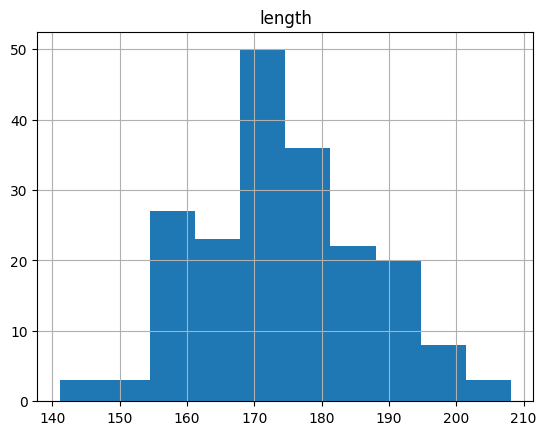

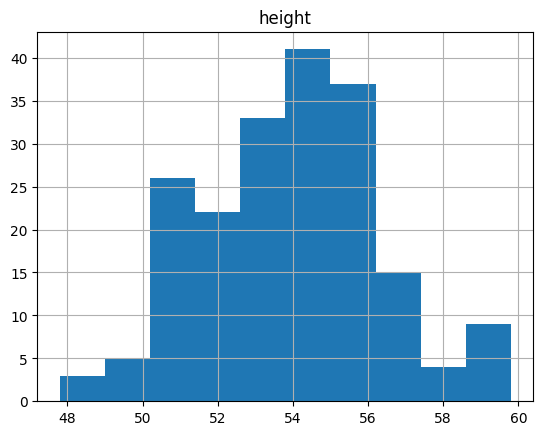

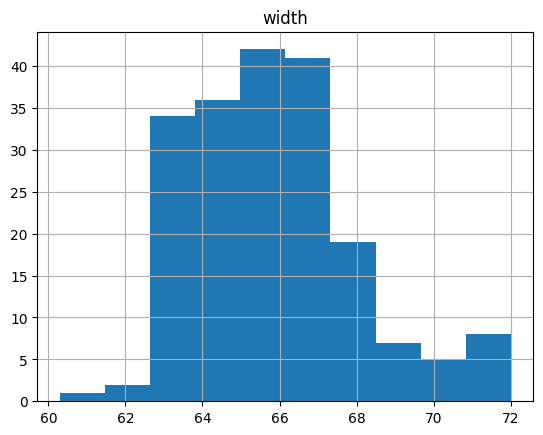

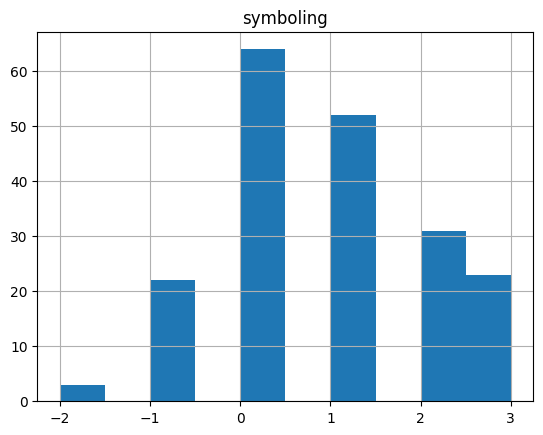

In [54]:
# This 1D visualization of each numeric feature might inform your normalization
# decisions.
for feature_name in numeric_feature_names:
  car_data.hist(column=feature_name)

### Train your model with numeric features + normalization

Trial 18 Complete [00h 00m 13s]
mse: 22888880.0

Best mse So Far: 19961299.0
Total elapsed time: 00h 04m 07s
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 137271120.0000 - mse: 137271120.0000 - val_loss: 35519020.0000 - val_mse: 35519020.0000
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 52736152.0000 - mse: 52736152.0000 - val_loss: 33100748.0000 - val_mse: 33100748.0000
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31916570.0000 - mse: 31916570.0000 - val_loss: 22856628.0000 - val_mse: 22856628.0000
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 23791814.0000 - mse: 23791814.0000 - val_loss: 15847742.0000 - val_mse: 15847742.0000
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21838610.0000 - mse: 21838610.0000 - val_loss: 16727473.0000 - val_mse: 16727473.0000
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20907250.0000 - mse: 20907250.0000 - val_loss: 17897568.0000 - val_mse: 17897568.0000
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22048174.0000 - mse: 22048174.0000 - val_loss: 18769566.0000 - val_mse: 18769566

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 212533856.0000 - mse: 212533856.0000 - val_loss: 110067816.0000 - val_mse: 110067816.0000
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 56866784.0000 - mse: 56866784.0000 - val_loss: 39482232.0000 - val_mse: 39482232.0000
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 26537972.0000 - mse: 26537972.0000 - val_loss: 14630837.0000 - val_mse: 14630837.0000
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 15570427.0000 - mse: 15570427.0000 - val_loss: 14288135.0000 - val_mse: 14288135.0000
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 12225876.0000 - mse: 12225876.0000 - val_loss: 13763647.0000 - val_mse: 13763647.0000
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9649564.0000 - mse: 9649564.0000 - val_loss: 13578227.0000 - val_mse: 13578227.0000
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8509578.0000 - mse: 8509578.0000 - val_loss: 13229665.0000 - val_mse: 13229665.0

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 209585728.0000 - mse: 209585728.0000 - val_loss: 96735856.0000 - val_mse: 96735856.0000
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 75813840.0000 - mse: 75813840.0000 - val_loss: 52145132.0000 - val_mse: 52145132.0000
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 30484706.0000 - mse: 30484706.0000 - val_loss: 23801460.0000 - val_mse: 23801460.0000
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 21390090.0000 - mse: 21390090.0000 - val_loss: 15177400.0000 - val_mse: 15177400.0000
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 16028370.0000 - mse: 16028370.0000 - val_loss: 13918799.0000 - val_mse: 13918799.0000
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 11717442.0000 - mse: 11717442.0000 - val_loss: 13675577.0000 - val_mse: 13675577.0000
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10163839.0000 - mse: 10163839.0000 - val_loss: 11022808.0000 - val_mse: 11022808

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 51326352.0000 - mse: 51326352.0000 - val_loss: 29878836.0000 - val_mse: 29878836.0000
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 41008456.0000 - mse: 41008456.0000 - val_loss: 29320750.0000 - val_mse: 29320750.0000
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 38462196.0000 - mse: 38462196.0000 - val_loss: 25261868.0000 - val_mse: 25261868.0000
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29128872.0000 - mse: 29128872.0000 - val_loss: 27416192.0000 - val_mse: 27416192.0000
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 32744638.0000 - mse: 32744638.0000 - val_loss: 47680160.0000 - val_mse: 47680160.0000
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 36811824.0000 - mse: 36811824.0000 - val_loss: 13734242.0000 - val_mse: 13734242.0000
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22973012.0000 - mse: 22973012.0000 - val_loss: 16521021.0000 - val_mse: 16521021.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 210948624.0000 - mse: 210948624.0000 - val_loss: 95846896.0000 - val_mse: 95846896.0000
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 53144792.0000 - mse: 53144792.0000 - val_loss: 26183210.0000 - val_mse: 26183210.0000
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 20627346.0000 - mse: 20627346.0000 - val_loss: 19187516.0000 - val_mse: 19187516.0000
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 13213813.0000 - mse: 13213813.0000 - val_loss: 14814385.0000 - val_mse: 14814385.0000
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 11321310.0000 - mse: 11321310.0000 - val_loss: 13807575.0000 - val_mse: 13807575.0000
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11004830.0000 - mse: 11004830.0000 - val_loss: 15292692.0000 - val_mse: 15292692.0000
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9850329.0000 - mse: 9850329.0000 - val_loss: 12584258.0000 - val_mse: 12584258.0

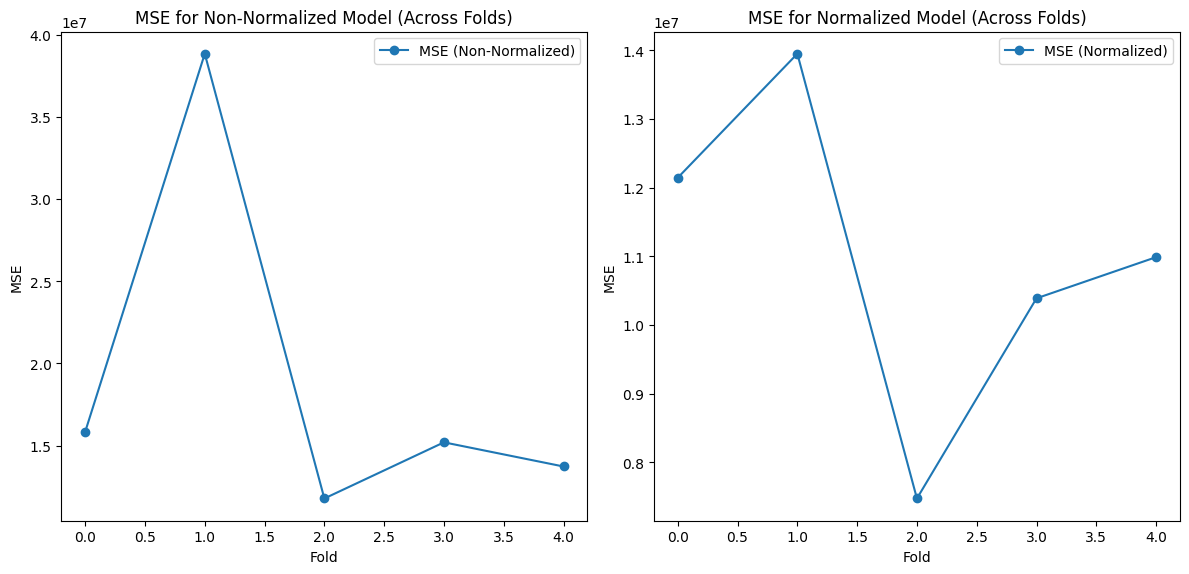

In [59]:
# Prepare data
x_df = car_data[numeric_feature_names]
y_series = car_data['price']

# Normalize the data
scaler = StandardScaler()
x_norm = scaler.fit_transform(x_df)

# Delete the previous tuner results to start fresh
shutil.rmtree('tuner_results', ignore_errors=True)

# Define the model-building function
def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_input', min_value=64, max_value=128, step=32),
                    activation='relu', input_dim=x_df.shape[1]))
    for i in range(hp.Int('num_layers', 1, 2)):  # 1 to 2 hidden layers
        model.add(Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=64, step=16), activation='relu'))
    model.add(Dense(1, activation='linear'))


    optimizer = Adam(learning_rate=0.1)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])

    return model


# Initialize the Keras Tuner with Random Search
tuner = kt.RandomSearch(
    build_model,
    objective='mse',
    max_trials=18,
    executions_per_trial=2,
    directory='tuner_results',
    project_name='car_price_prediction'
)

# Display summary of the search space
tuner.search_space_summary()

# Initialize KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics across all folds
mse_scores_non_norm = []
mse_scores_norm = []
mae_scores_non_norm = []
mae_scores_norm = []
r2_scores_non_norm = []
r2_scores_norm = []

# K-fold cross-validation
for train_index, val_index in kf.split(x_df):
    X_train, X_val = x_df.iloc[train_index], x_df.iloc[val_index]
    y_train, y_val = y_series.iloc[train_index], y_series.iloc[val_index]

    # Normalize the data for each fold
    X_train_norm = scaler.fit_transform(X_train)
    X_val_norm = scaler.transform(X_val)

    # ** Train model on non-normalized data **
    print("Training model on non-normalized data...")
    # Perform the hyperparameter search only once, and get the best model
    tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
    best_model_non_norm = tuner.get_best_models(num_models=1)[0]
    # Fit the model using the best hyperparameters found
    best_model_non_norm.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])

    # ** Train model on normalized data **
    print("Training model on normalized data...")
    # Perform a second search for the normalized data (with normalization applied)
    tuner.search(X_train_norm, y_train, epochs=10, validation_data=(X_val_norm, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
    best_model_norm = tuner.get_best_models(num_models=1)[0]
    # Fit the best model on normalized data
    best_model_norm.fit(X_train_norm, y_train, epochs=10, batch_size=16, validation_data=(X_val_norm, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])

    # Evaluate non-normalized model
    mse_non_norm = best_model_non_norm.evaluate(X_val, y_val, verbose=0)[1]
    mse_scores_non_norm.append(mse_non_norm)

    # Evaluate normalized model
    mse_norm = best_model_norm.evaluate(X_val_norm, y_val, verbose=0)[1]
    mse_scores_norm.append(mse_norm)

    # Predict and calculate metrics for non-normalized model
    y_pred_non_norm = best_model_non_norm.predict(X_val)
    mae_non_norm = mean_absolute_error(y_val, y_pred_non_norm)
    r2_non_norm = r2_score(y_val, y_pred_non_norm)
    mae_scores_non_norm.append(mae_non_norm)
    r2_scores_non_norm.append(r2_non_norm)

    # Predict and calculate metrics for normalized model
    y_pred_norm = best_model_norm.predict(X_val_norm)
    mae_norm = mean_absolute_error(y_val, y_pred_norm)
    r2_norm = r2_score(y_val, y_pred_norm)
    mae_scores_norm.append(mae_norm)
    r2_scores_norm.append(r2_norm)

# Calculate average performance across all folds
print(f"\nAverage MSE (Non-Normalized): {np.mean(mse_scores_non_norm)}")
print(f"Average MSE (Normalized): {np.mean(mse_scores_norm)}")

print(f"Average MAE (Non-Normalized): {np.mean(mae_scores_non_norm)}")
print(f"Average MAE (Normalized): {np.mean(mae_scores_norm)}")

print(f"Average R² (Non-Normalized): {np.mean(r2_scores_non_norm)}")
print(f"Average R² (Normalized): {np.mean(r2_scores_norm)}")

# Optionally visualize performance metrics
plt.figure(figsize=(12, 6))

# Non-normalized model MSE plot
plt.subplot(1, 2, 1)
plt.plot(mse_scores_non_norm, label='MSE (Non-Normalized)', marker='o')
plt.title('MSE for Non-Normalized Model (Across Folds)')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.legend()

# Normalized model MSE plot
plt.subplot(1, 2, 2)
plt.plot(mse_scores_norm, label='MSE (Normalized)', marker='o')
plt.title('MSE for Normalized Model (Across Folds)')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()

## Best model using only categorical features

- Look at the possible feature columns for categorical features. They begin with `categorical_column_with_` in go/tf-ops.
- You may find `dataframe[categorical_feature_names].unique()` helpful.


Trial 18 Complete [00h 00m 14s]
mse: 48274374.0

Best mse So Far: 37970220.0
Total elapsed time: 00h 04m 12s
Optimal hyperparameters for categorical model:
Optimizer: Adagrad
Learning Rate: 0.1
Batch Size: 24
Units in layer 1: 48
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 179147792.0000 - mse: 179147776.0000 - val_loss: 111015304.0000 - val_mse: 111015304.0000
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 79972360.0000 - mse: 79972360.0000 - val_loss: 93470728.0000 - val_mse: 93470728.0000
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 59463920.0000 - mse: 59463920.0000 - val_loss: 55030352.0000 - val_mse: 55030352.0000
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 51179504.0000 - mse: 51179504.0000 - val_loss: 74969984.0000 - val_mse: 74969984.0000
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 42249888.0000 - mse: 42249888.0000 - val_loss: 27002010.0000 - val_mse: 27002010.0000
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - 

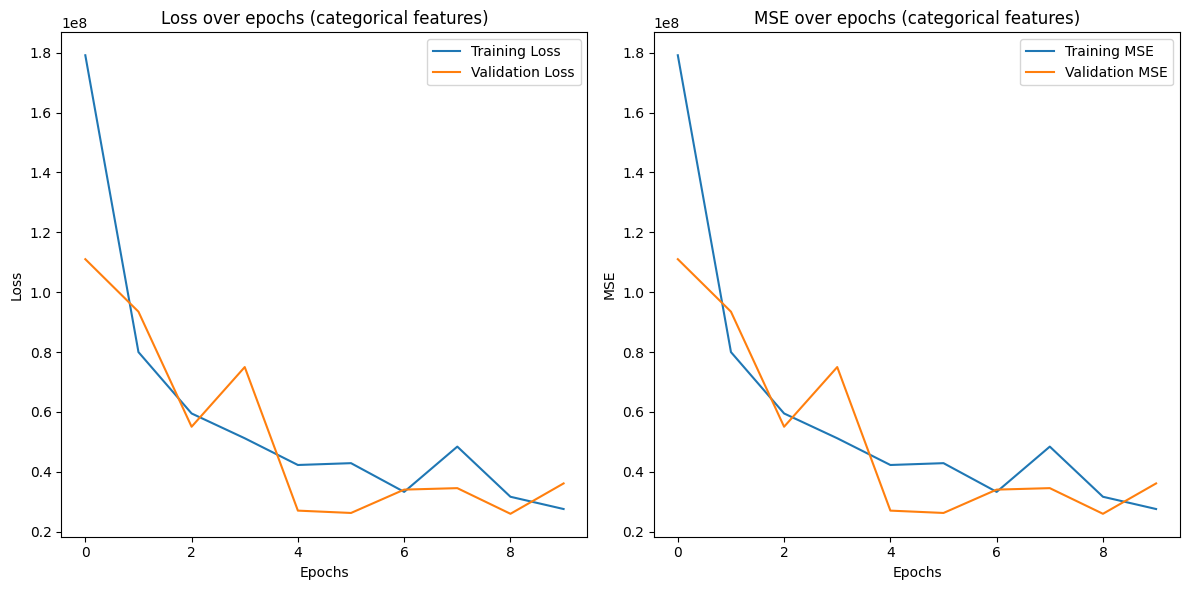

In [60]:
# Encode categorical features using one-hot encoding
car_data_encoded = pd.get_dummies(car_data, columns=categorical_feature_names)

# Define input and output for the categorical model
x_df_cat = car_data_encoded.drop(columns=[LABEL])
y_series_cat = car_data_encoded[LABEL]

# Split into training and testing sets
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(x_df_cat, y_series_cat, test_size=0.2, random_state=42)

# Ensure all data types are numeric and FLOAT
X_train_cat = X_train_cat.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)
X_test_cat = X_test_cat.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)
y_train_cat = pd.to_numeric(y_train_cat, errors='coerce').fillna(y_train_cat.mean()).astype(np.float32)
y_test_cat = pd.to_numeric(y_test_cat, errors='coerce').fillna(y_test_cat.mean()).astype(np.float32)

# Convert to numpy arrays
X_train_cat = X_train_cat.values
X_test_cat = X_test_cat.values
y_train_cat = y_train_cat.values
y_test_cat = y_test_cat.values

# Delete previous tuner results to start fresh
shutil.rmtree('tuner_results_cat', ignore_errors=True)

# Define the model-building function with Keras Tuner hyperparameters
def build_categorical_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_input', min_value=64, max_value=128, step=32),
                    activation='relu', input_dim=X_train_cat.shape[1]))

    for i in range(hp.Int('num_layers', 1, 2)):  # 1 to 2 hidden layers
        model.add(Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=64, step=16), activation='relu'))

    model.add(Dense(1, activation='linear'))

    optimizer_name = hp.Choice('optimizer', ['Adagrad', 'Adam', 'RMSprop'])
    learning_rate = hp.Choice('learning_rate', [0.01, 0.001, 0.1])

    if optimizer_name == 'Adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)

    batch_size = hp.Int('batch_size', 16, 32, step=8)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])
    return model

# Initialize the Keras Tuner with Random Search for categorical features
tuner_cat = kt.RandomSearch(
    build_categorical_model,
    objective='mse',
    max_trials=18,
    executions_per_trial=2,
    directory='tuner_results_cat',
    project_name='car_price_prediction_cat'
)

tuner_cat.search_space_summary()

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Conduct the hyperparameter search
tuner_cat.search(X_train_cat, y_train_cat, epochs=10, validation_split=0.2, callbacks=[early_stopping])

# Retrieve the best hyperparameters
best_hps_cat = tuner_cat.get_best_hyperparameters(num_trials=1)[0]
print("Optimal hyperparameters for categorical model:")
print(f"Optimizer: {best_hps_cat.get('optimizer')}")
print(f"Learning Rate: {best_hps_cat.get('learning_rate')}")
print(f"Batch Size: {best_hps_cat.get('batch_size')}")
for i in range(best_hps_cat.get('num_layers')):
    print(f"Units in layer {i+1}: {best_hps_cat.get(f'units_{i}')}")

# Build the best model and fit it on the full dataset for categorical features
best_model_cat = tuner_cat.hypermodel.build(best_hps_cat)
history_cat = best_model_cat.fit(X_train_cat, y_train_cat, epochs=10, batch_size=best_hps_cat.get('batch_size'), validation_split=0.2)

# Evaluate the model's performance
loss_cat, mse_cat = best_model_cat.evaluate(X_test_cat, y_test_cat)
print(f"Final MSE on test set (categorical): {mse_cat}")

# Predictions and additional metrics
y_pred_cat = best_model_cat.predict(X_test_cat)
mae_cat = mean_absolute_error(y_test_cat, y_pred_cat)
r2_cat = r2_score(y_test_cat, y_pred_cat)

print(f"Mean Absolute Error (MAE) for categorical model: {mae_cat}")
print(f"R² Score for categorical model: {r2_cat}")

#Retrieve the list of trials
trials = tuner_cat.oracle.trials

# Prepare the data for the table
optimizer_list = []
learning_rate_list = []
loss_list = []

# Loop through each trial and extract the relevant data
for trial in trials.values():
    # Get hyperparameters
    optimizer = trial.hyperparameters['optimizer']
    learning_rate = trial.hyperparameters['learning_rate']
    loss = trial.metrics.get_best_value('loss')

    # Append the values to their respective lists
    optimizer_list.append(optimizer)
    learning_rate_list.append(learning_rate)
    loss_list.append(loss)

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Optimizer': optimizer_list,
    'Learning Rate': learning_rate_list,
    'Training Loss': loss_list
})

# Convert results_df['Training Loss'] to numeric to ensure aggregation works properly
results_df['Training Loss'] = pd.to_numeric(results_df['Training Loss'], errors='coerce')

# Group by 'Optimizer' and 'Learning Rate' and take the minimum loss for each combination
results_df = results_df.groupby(['Optimizer', 'Learning Rate'], as_index=False).min()

# Sort by training loss to see the best combinations
results_df = results_df.sort_values(by=['Optimizer', 'Learning Rate'], ascending=[True, True])

# Apply formatting only to the 'Learning Rate' column
results_df['Learning Rate'] = results_df['Learning Rate'].map('{:.3f}'.format)

# Display the comparison table
print("Comparison of Optimizers and Learning Rates:")
print(results_df)

# Visualize training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_cat.history['loss'], label='Training Loss')
plt.plot(history_cat.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs (categorical features)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cat.history['mse'], label='Training MSE')
plt.plot(history_cat.history['val_mse'], label='Validation MSE')
plt.title('MSE over epochs (categorical features)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()


## Best model using all the features

With all the features combined, model should perform better than earlier models using numerical and categorical models alone.

Trial 24 Complete [00h 00m 25s]
mse: 1628042.28125

Best mse So Far: 1.2315975030263264
Total elapsed time: 00h 08m 39s
Optimal hyperparameters for model with all features:
Optimizer: Adagrad
Learning Rate: 0.01
Batch Size: 24
Units in layer 1: 64
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 95641360.0000 - mse: 95641360.0000 - val_loss: 2582035.0000 - val_mse: 2582035.0000
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 936394.2500 - mse: 936394.2500 - val_loss: 3522.4492 - val_mse: 3522.4492
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1131.5608 - mse: 1131.5608 - val_loss: 4.5543 - val_mse: 4.5543
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.2855 - mse: 2.2855 - val_loss: 1.3563 - val_mse: 1.3563
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3384 - mse: 1.3384 - val_loss: 1.3106 - val_mse: 1.3106
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3485 - mse: 1.3485 - val_loss: 1.3063 - val_mse: 1.3063
Epoch 7/10
6/6

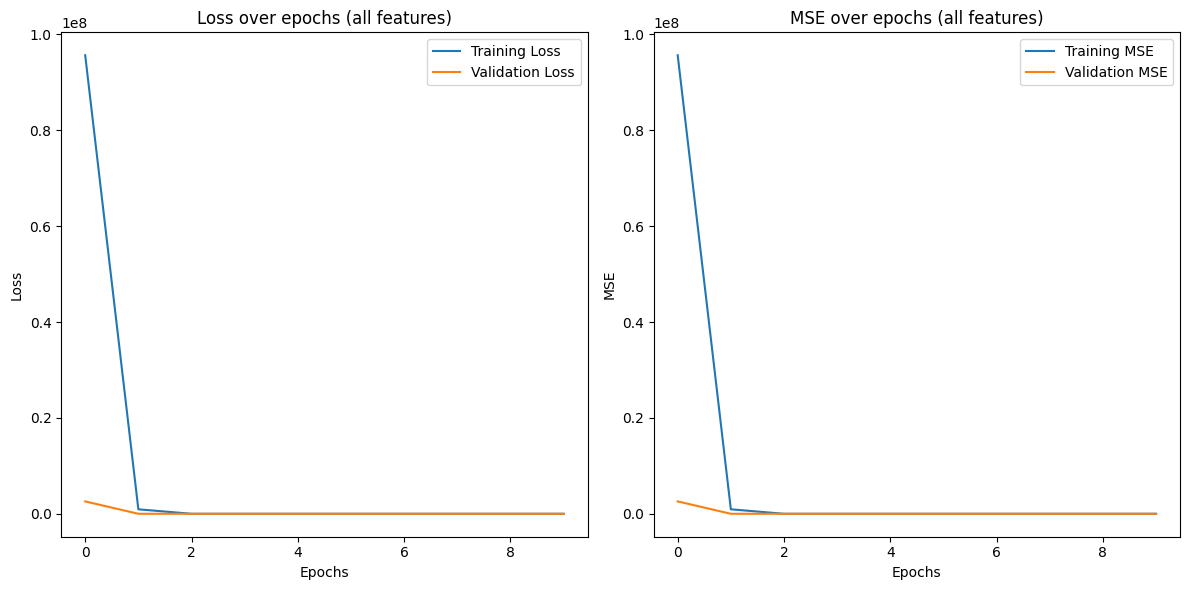

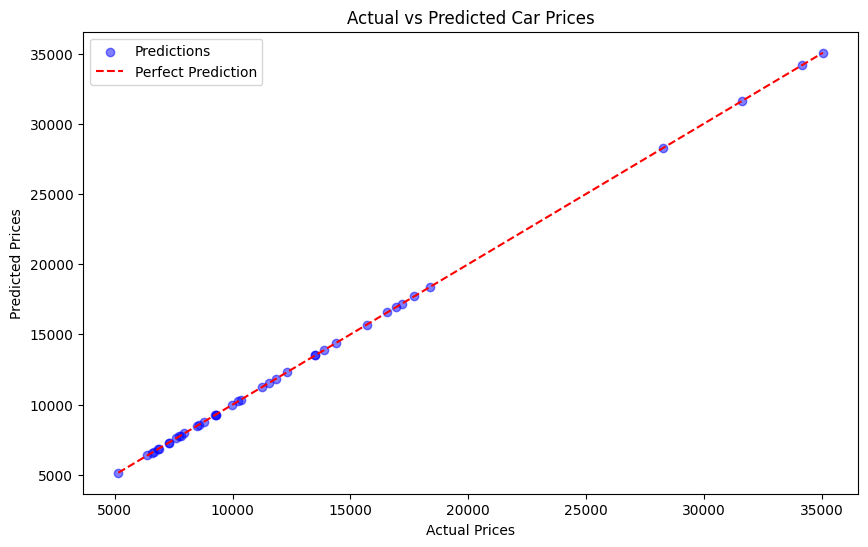

In [61]:
# Encode categorical features using one-hot encoding
car_data_encoded = pd.get_dummies(car_data, columns=categorical_feature_names)

# Normalize the numerical data
x_df = car_data[numeric_feature_names]
scaler = StandardScaler()
x_norm = scaler.fit_transform(x_df)

# Get the list of all columns in the encoded DataFrame (this includes one-hot encoded columns)
categorical_encoded_columns = [col for col in car_data_encoded.columns if col not in numeric_feature_names]

# Concatenate normalized numerical features with one-hot encoded categorical features
x_combined = np.concatenate([x_norm, car_data_encoded[categorical_encoded_columns]], axis=1)
y_combined = car_data[LABEL]

# Ensure data is of the correct type (float32)
x_combined = np.array(x_combined, dtype=np.float32)
y_combined = np.array(y_combined, dtype=np.float32)

# Split the data into training and testing sets
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(x_combined, y_combined, test_size=0.2, random_state=42)

# Delete previous tuner results to start fresh
shutil.rmtree('tuner_results_all', ignore_errors=True)

# Define the model-building function with Keras Tuner hyperparameters
def build_all_features_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_input', min_value=64, max_value=128, step=32),
                    activation='relu', input_dim=X_train_all.shape[1]))

    for i in range(hp.Int('num_layers', 1, 2)):  # 1 to 2 hidden layers
        model.add(Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=64, step=16), activation='relu'))

    model.add(Dense(1, activation='linear'))

    optimizer_name = hp.Choice('optimizer', ['Adagrad', 'Adam', 'RMSprop'])
    learning_rate = hp.Choice('learning_rate', [0.0001, 0.001, 0.01])

    if optimizer_name == 'Adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)

    batch_size = hp.Int('batch_size', 16, 32, step=8)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])
    return model

# Initialize the Keras Tuner with Random Search for all features
tuner_all = kt.RandomSearch(
    build_all_features_model,
    objective='mse',
    max_trials=24,
    executions_per_trial=3,
    directory='tuner_results_all',
    project_name='car_price_prediction_all'
)

tuner_all.search_space_summary()

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Conduct the hyperparameter search
tuner_all.search(X_train_all, y_train_all, epochs=10, validation_split=0.2, callbacks=[early_stopping])

# Retrieve the best hyperparameters
best_hps_all = tuner_all.get_best_hyperparameters(num_trials=1)[0]
print("Optimal hyperparameters for model with all features:")
print(f"Optimizer: {best_hps_all.get('optimizer')}")
print(f"Learning Rate: {best_hps_all.get('learning_rate')}")
print(f"Batch Size: {best_hps_all.get('batch_size')}")
for i in range(best_hps_all.get('num_layers')):
    print(f"Units in layer {i+1}: {best_hps_all.get(f'units_{i}')}")

# Build the best model and fit it on the full dataset for all features
best_model_all = tuner_all.hypermodel.build(best_hps_all)
history_all = best_model_all.fit(X_train_all, y_train_all, epochs=10, batch_size=best_hps_all.get('batch_size'), validation_split=0.2)

# Evaluate the model's performance
loss_all, mse_all = best_model_all.evaluate(X_test_all, y_test_all)
print(f"Final MSE on test set (all features): {mse_all}")

# Predictions and additional metrics
y_pred_all = best_model_all.predict(X_test_all)
mae_all = mean_absolute_error(y_test_all, y_pred_all)
r2_all = r2_score(y_test_all, y_pred_all)

print(f"Mean Absolute Error (MAE) for model with all features: {mae_all}")
print(f"R² Score for model with all features: {r2_all}")

#Retrieve the list of trials
trials = tuner_all.oracle.trials

# Prepare the data for the table
optimizer_list = []
learning_rate_list = []
loss_list = []

# Loop through each trial and extract the relevant data
for trial in trials.values():
    # Get hyperparameters
    optimizer = trial.hyperparameters['optimizer']
    learning_rate = trial.hyperparameters['learning_rate']
    loss = trial.metrics.get_best_value('loss')

    # Append the values to their respective lists
    optimizer_list.append(optimizer)
    learning_rate_list.append(learning_rate)
    loss_list.append(loss)

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Optimizer': optimizer_list,
    'Learning Rate': learning_rate_list,
    'Training Loss': loss_list
})

# Convert results_df['Training Loss'] to numeric to ensure aggregation works properly
results_df['Training Loss'] = pd.to_numeric(results_df['Training Loss'], errors='coerce')

# Group by 'Optimizer' and 'Learning Rate' and take the minimum loss for each combination
results_df = results_df.groupby(['Optimizer', 'Learning Rate'], as_index=False).min()

# Sort by training loss to see the best combinations
results_df = results_df.sort_values(by=['Optimizer', 'Learning Rate'], ascending=[True, True])

# Apply formatting only to the 'Learning Rate' column
results_df['Learning Rate'] = results_df['Learning Rate'].map('{:.4f}'.format)

# Display the comparison table
print("Comparison of Optimizers and Learning Rates:")
print(results_df)

# Visualize training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_all.history['loss'], label='Training Loss')
plt.plot(history_all.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs (all features)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_all.history['mse'], label='Training MSE')
plt.plot(history_all.history['val_mse'], label='Validation MSE')
plt.title('MSE over epochs (all features)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()

# Visualize the model's predictions vs actual values (y_test_all)
plt.figure(figsize=(10, 6))

# Scatter plot to show the actual vs predicted prices
plt.scatter(y_test_all, y_pred_all, color='blue', alpha=0.5, label='Predictions')

# Add a line for perfect predictions (y = x)
plt.plot([y_test_all.min(), y_test_all.max()], [y_test_all.min(), y_test_all.max()], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()

plt.show()

In [65]:
!pip freeze | grep -v "file:///" > requirements.txt